In [1]:
from astropy.wcs import WCS
from astropy import units as u
from astropy.io import fits
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors
from scipy import stats
import h5py
import numpy as np
from brutus import filters
from brutus.utils import inv_magnitude
from brutus import fitting
from brutus.los import LOS_clouds_priortransform as ptform
from brutus.los import LOS_clouds_loglike_samples as loglike
from zero_point import zpt
from dynesty import plotting as dyplot
import math
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 15
rcParams["mathtext.fontset"] = 'stix'
%config InlineBackend.figure_format='retina' 

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [3]:
from pipeline import process_cg_region, query_region, clean_and_fit, fit_wo_Mdwarf, run_nested_sampling, make_plots 
base = '/Users/anniegao/Documents/CG_mapping_files/'#2-star_modeling/output/

Could not import regions, which is required for some of the functionalities of this module.


In [4]:
CG_table = pd.read_csv('/Users/anniegao/Documents/dustmaps_files/CG_w_tails.csv')
CG_table

,Name,ra,dec,tail-end-ra,tail-end-dec,ra_deg,dec_deg,tail_ra_deg,tail_dec_deg
0,CG01,7h17m49.7s,-44d29m26.2s,7h15m39.4s,-44d29m2s,109.839618,-44.584222,109.295912,-44.575009
1,CG02,7h14m31.3s,-43d52m43.8s,7h12m49.3s,-43d51m24.6s,109.017151,-43.968661,108.591721,-43.944702
2,CG03,7h37m45.9s,-47d45m35.1s,7h37m26s,-47d47m51.4s,114.802478,-47.875747,114.719006,-47.913240
3,CG04,7h32m45.6s,-46d50m8.9s,7h30m40.5s,-46d56m43.2s,113.557516,-46.946260,113.034160,-47.053453
4,CG05,7h39m15.8s,-43d42m8.3s,7h39m4.6s,-43d41m55.1s,115.214758,-43.820036,115.168031,-43.816164
5,CG06,7h29m2.1s,-46d37m14.5s,7h28m18.9s,-46d41m35s,112.626465,-46.726980,112.445422,-46.798530
6,CG07,9h12m26.1s,-42d16m54.4s,9h13m14.2s,-42d18m14.6s,138.580425,-42.489818,138.781374,-42.512743
7,CG08,7h41m1.3s,-41d8m32.8s,7h40m46.5s,-41d8m23.2s,115.675892,-41.262154,115.614134,-41.259217
8,CG09,7h39m7.4s,-41d20m4.4s,7h38m52.6s,-41d19m6.3s,115.198955,-41.452174,115.137304,-41.435763
9,CG10,7h40m55.2s,-41d58m11.9s,7h40m34.6s,-41d59m48.4s,115.643925,-42.089556,115.557718,-42.115984


In [5]:
akari_image_path = '/Users/anniegao/Documents/CG_mapping_files/Akari/'

akari = fits.open(akari_image_path+'CG05_l136.06_b-65.00_ecl_6deg_N160_fixstripe.fits')[0]
wcs = WCS(akari.header)

In [7]:
cg_queries_path = '/Users/anniegao/Documents/CG_mapping_files/1-queried_stars/'
cg_num = 'CG05'
cg_stars = pd.read_csv(cg_queries_path+f'{cg_num}_decaps_2mass_gaia.csv')
# import M Dwarf
# cg_mdwarf_path = '/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/'
# cg_mdwarf = pd.read_csv(cg_mdwarf_path+f'{cg_num}_Mdwarf_res.csv')

'CG05'

In [139]:
x_pixel.min(), x_pixel.max(), y_pixel.min(), y_pixel.max(), emission.min(), emission.max()

(142.71871099547684,
 163.74589473724473,
 1091.0081014765096,
 1106.4918422631458,
 121.1848,
 163.45139)

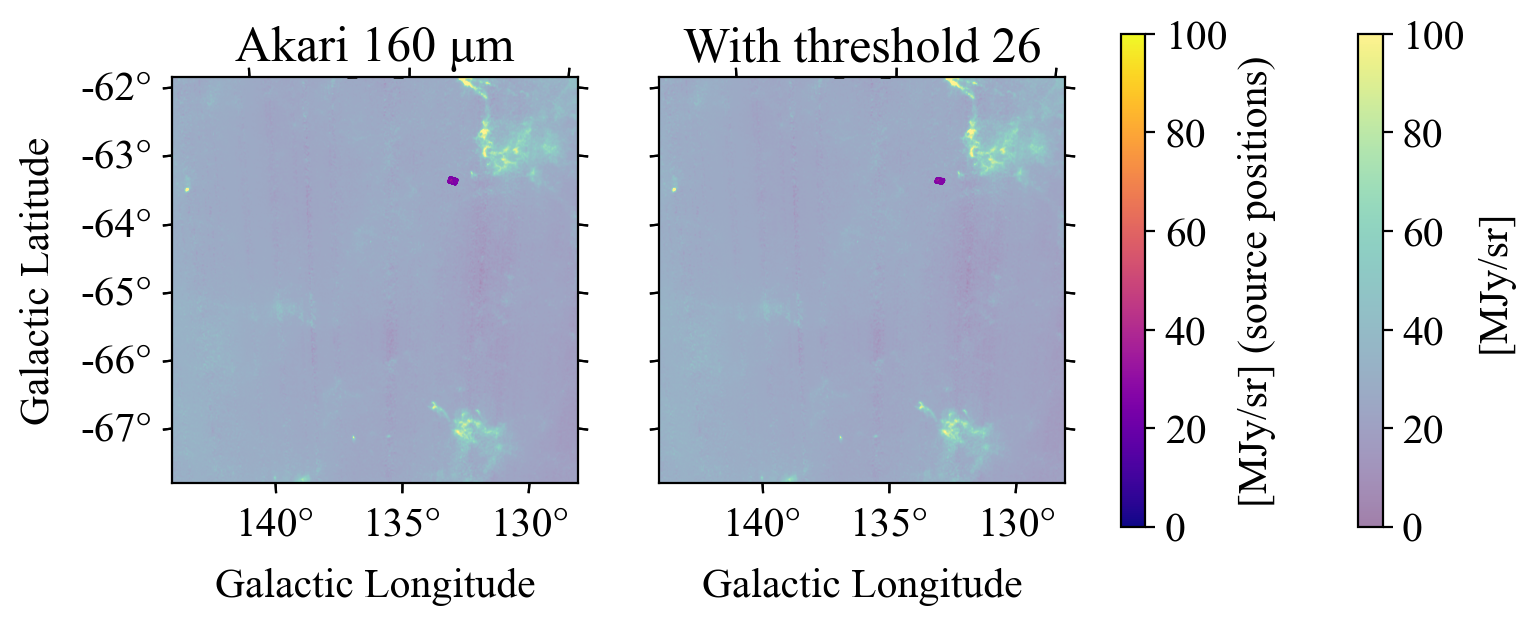

In [7]:
x_pixel, y_pixel = wcs.world_to_pixel_values(cg_stars['elon'], cg_stars['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
emission = akari.data[y,x]
# set the threshold
em_val = 26
mask = emission> em_val
a_sel, b_sel = x_pixel[mask], y_pixel[mask]
emission_sel = emission[mask]
# Shared normalization
norm = colors.Normalize(vmin=0, vmax= math.ceil(emission.max() / 100) * 100) #find the nearest hundred
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (9,4), subplot_kw=dict(projection=wcs))
im1 = ax1.imshow(akari.data, origin='lower', norm = norm, alpha = 0.5) # vmin=20, vmax=300, alpha=0.1
sc1 = ax1.scatter(x = x_pixel, y = y_pixel, s=0.05, c=emission,cmap='plasma', norm = norm, alpha=1) 
ax1.set_title('Akari 160 μm')
ax1.set_xlabel('Galactic Longitude') 
ax1.set_ylabel('Galactic Latitude') 
# ax1.set_xlim(100, 220)
# ax1.set_ylim(1000,  1120)

im2 = ax2.imshow(akari.data, origin='lower', norm = norm, alpha=0.5) #, alpha=0.1
sc2 = ax2.scatter(x = a_sel, y = b_sel, s=0.05, c=emission_sel, cmap='plasma', norm = norm, alpha=1) 
ax2.set_title(f'With threshold {em_val}')
ax2.set_xlabel('Galactic Longitude') 
ax2.coords[1].set_ticklabel_visible(False)
ax2.coords[1].set_axislabel('')
# ax2.set_xlim(100, 220)
# ax2.set_ylim(1000,  1120)

cbar = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.8)
cbar.set_label('[MJy/sr]')
cbar2 = plt.colorbar(sc1, ax=[ax1, ax2], shrink=0.8)
cbar2.set_label('[MJy/sr] (source positions)')


In [8]:
region_name = f'Akari_{cg_num}_emission{em_val}'
data_queried = cg_stars[mask]
region_name

'Akari_CG05_emission26'

In [733]:
region_name = f'Akari_{cg_num}_emission{em_val}'
data_queried = cg_stars[mask]
merged_table_selected, parallax, parallax_err = fit_wo_Mdwarf(data_queried, base, region_name) #

DECam_g (0.0%)
DECam_r (-4.0%)
DECam_i (-5.0%)
DECam_z (-4.0%)
DECam_Y (-5.0%)
2MASS_J (-2.0%)
2MASS_H (4.0%)
2MASS_Ks (3.0%)
Reading filter 2MASS_Ks           
/Users/anniegao/Documents/Research/Cometary_Globules/pipeline.py:245: RuntimeWarning: divide by zero encountered in log10
  mag_decam = -2.5*np.log10(flux_decam)
/Users/anniegao/Documents/Research/Cometary_Globules/pipeline.py:246: RuntimeWarning: invalid value encountered in divide
  magerr_decam = 1.086*flux_decam_err/flux_decam
Fitting object 110/110 [chi2/n: 7.7/5] (mean time: 0.647 s/obj, est. time remaining:      0.000 s)    


Fitted result saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG05_emission26_cut22.h5
Selected Mdwarf table saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/Akari_CG05_emission26_cut22_allstar.csv
Saved modified parallax and parallax_err too.


In [9]:
with np.load(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_parallax.npz") as data:
    parallax = data['parallax']
    parallax_err = data['parallax_err']

In [10]:
filename = f'{base}2-star_modeling/output/'
import brutus
import dynesty
# selected_table = pd.read_csv(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_Mdwarf.csv")

f = h5py.File(f'/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_{cg_num}_emission{em_val}.h5', 'r')
chi2_mist =f['obj_chi2min'] #best fit chi2
nbands_mist = f['obj_Nbands']# number of bands in fit
dists_mist = f['samps_dist'] # distance samples
reds_mist = f['samps_red'] # A(V) samples
dreds_mist = f['samps_dred']# R(V) samples
good=(stats.chi2.sf(chi2_mist, nbands_mist) > 0.01)
dists_mist = np.array(dists_mist)[good, :]
reds_mist = np.array(reds_mist)[good, :]
dreds_mist = np.array(dreds_mist)[good, :]

# plx_data = np.load(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_parallax.npz")
# parallax, parallax_err = plx_data['parallax'], plx_data['parallax_err']
pdfbin, xedges, yedges = brutus.pdf.bin_pdfs_distred((dists_mist, reds_mist, dreds_mist), 
                                                    parallaxes = parallax,  # limits smoothing
                                                    parallax_errors=parallax_err,  # if parallax SNR is high
                                                    #  avlim=(0., 4.5),
                                                    )
N_stars = pdfbin.shape[0]
max_positions = np.argmax(pdfbin.reshape(N_stars, -1), axis=1)
x_idx, y_idx = np.unravel_index(max_positions, (750, 300))  # shape: (N_stars,)
x_centers = 0.5 * (xedges[:-1] + xedges[1:])  # shape: (750,)
y_centers = 0.5 * (yedges[:-1] + yedges[1:])  # shape: (300,)
x_max = x_centers[x_idx] 
y_max = y_centers[y_idx]
plot_path = '/Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/plots'
# np.savez(f"{plot_path}/{region_name}_individual_star_samples.npz",
#         good=good,
#         x_max=x_max,
#         y_max=y_max,
#         xedges=xedges,
#         yedges=yedges,
#         pdfbin = pdfbin)

In [30]:
pdfbin.shape, max_positions

((245, 750, 300),
 array([123315,  56117, 122739, 149777, 157263, 111600, 159732, 166875,
        131468, 111322, 120600, 148828, 113759, 150957, 139355, 137100,
        118500, 151055, 146782, 165688, 113222, 102369,  96643, 156692,
        152175, 165121, 120981, 140238, 144670, 153693, 130546, 112258,
        157007, 153387, 100500, 137453, 117323, 131100, 119762, 119471,
        140459, 138900, 144371, 158186, 144771, 150669, 134180, 154589,
        102379, 165676, 134741, 146470, 126081, 155852,  82842, 132708,
        162427, 129395, 105025, 157580, 162681, 112200, 106850, 168986,
        113162, 157584, 127257, 126081, 154080, 148659, 153133, 159093,
        159128, 107459, 124800, 135099,  96348, 159982, 153115, 136323,
        166322, 154929,  65178, 138969, 142900, 148657, 105060, 122700,
        123068, 136500, 157255, 163882, 125765, 125786, 148200, 162708,
        151896, 159073, 131764, 153163, 135653, 162738, 157318, 148043,
        131521, 169936, 158537, 169909, 156127

In [19]:
pd_merged = pd.read_csv(f'{cg_mdwarf_path}{region_name}_allstar.csv')[good]
pd_merged['derived_dist'] = 10**( x_max/5 +1)
pd_merged['derived Av'] = y_max
x_pixel, y_pixel = wcs.world_to_pixel_values(pd_merged['elon'], pd_merged['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
akari_data = np.asarray(akari.data, dtype=np.float32)
emission = akari_data[y,x]
pd_merged['AKARI_emission_MJy_sr-1'] = emission
# pd_merged.to_csv(f'{base}2-star_modeling/M_dwarf_fit_results/{region_name}_allstar_res.csv', index= False)

In [23]:
em_val

26

In [ ]:
dists_mist0 = dists_mist
reds_mist0 = reds_mist
x_max0 = x_max
# em_val = 34
emission_mask = (emission> em_val) &(pd_merged['obj_id'].isin(cg_mdwarf['obj_id']))
dists_mist0 = dists_mist0[emission_mask]
reds_mist0 = reds_mist0[emission_mask] 
x_max0 = x_max0[emission_mask]
# pd_merged[emission_mask].to_csv(f'{base}2-star_modeling/M_dwarf_fit_results/{region_name}_Mdwarf_res.csv', index= False)

In [30]:
dist_mod = 4
10**(0.2*4+1)

63.09573444801933

In [22]:
# convert from kpc to distance modulus, add limit of 10 distance modulus to avoid confusion

import dynesty
dist_mist_new = dists_mist0 #[x_max0<10.5]
red_mist_new = reds_mist0#[x_max0<10.5]
dms_mist = 5. * np.log10(dist_mist_new) + 10
nclouds = 1  # number of clouds
ndim = 2 * nclouds + 4  # number of parameters

# adjust default distance modulus limits in ptform
ptform_kwargs = {'dlims': (6., 10.)}

# distances and extinctions to be passed to loglike
logl_args = [dms_mist, red_mist_new]
logl_kwargs = {'monotonic': True}  # extinctions must increase

# fit dust along the LOS with dynesty
sampler = dynesty.NestedSampler(loglike, ptform, ndim,
                                ptform_kwargs=ptform_kwargs,
                                logl_args=logl_args,
                                # logl_kwargs=logl_kwargs
                                )
sampler.run_nested(dlogz=0.01)
# save results
res = sampler.results

1668it [00:05, 118.24it/s, bound: 0 | nc: 36 | ncall: 16567 | eff(%): 10.068 | loglstar:   -inf < -19.623 <    inf | logz: -26.044 +/-    nan | dlogz: 23.740 >  0.010]/Users/anniegao/anaconda3/envs/ism/lib/python3.9/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
1691it [00:06, 39.84it/s, bound: 1 | nc: 55 | ncall: 17506 | eff(%):  9.660 | loglstar:   -inf < -18.809 <    inf | logz: -25.226 +/-    nan | dlogz: 22.876 >  0.010] /Users/anniegao/anaconda3/envs/ism/lib/python3.9/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping

In [24]:
import pickle
# pickle_name = f'{base}3-nested_sampling/results/{region_name}threshold{em_val}_allstar_nested_sampling_res.pkl'
pickle_name = f'{base}3-nested_sampling/results/{region_name}threshold{em_val}_mdwarf_nested_sampling_res.pkl'
with open(pickle_name, 'wb') as f:
    pickle.dump(res, f)
print(f'Nested Sampling result saved to {pickle_name}')

Nested Sampling result saved to /Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/results/Akari_CG05_emission26threshold26_mdwarf_nested_sampling_res.pkl


In [ ]:
# with open(f'{base}3-nested_sampling/results/CG28_nested_sampling_res.pkl', 'rb') as f:
#         res = pickle.load(f)
# mu_samples = res.samples[:, 4]

In [25]:
weights = np.exp(res.logwt - res.logz[-1])
samples_equal = dynesty.utils.resample_equal(res.samples, weights)
av0 = samples_equal[:, 3]
mu_samples = samples_equal[:, 4]
av1 = samples_equal[:, 5]

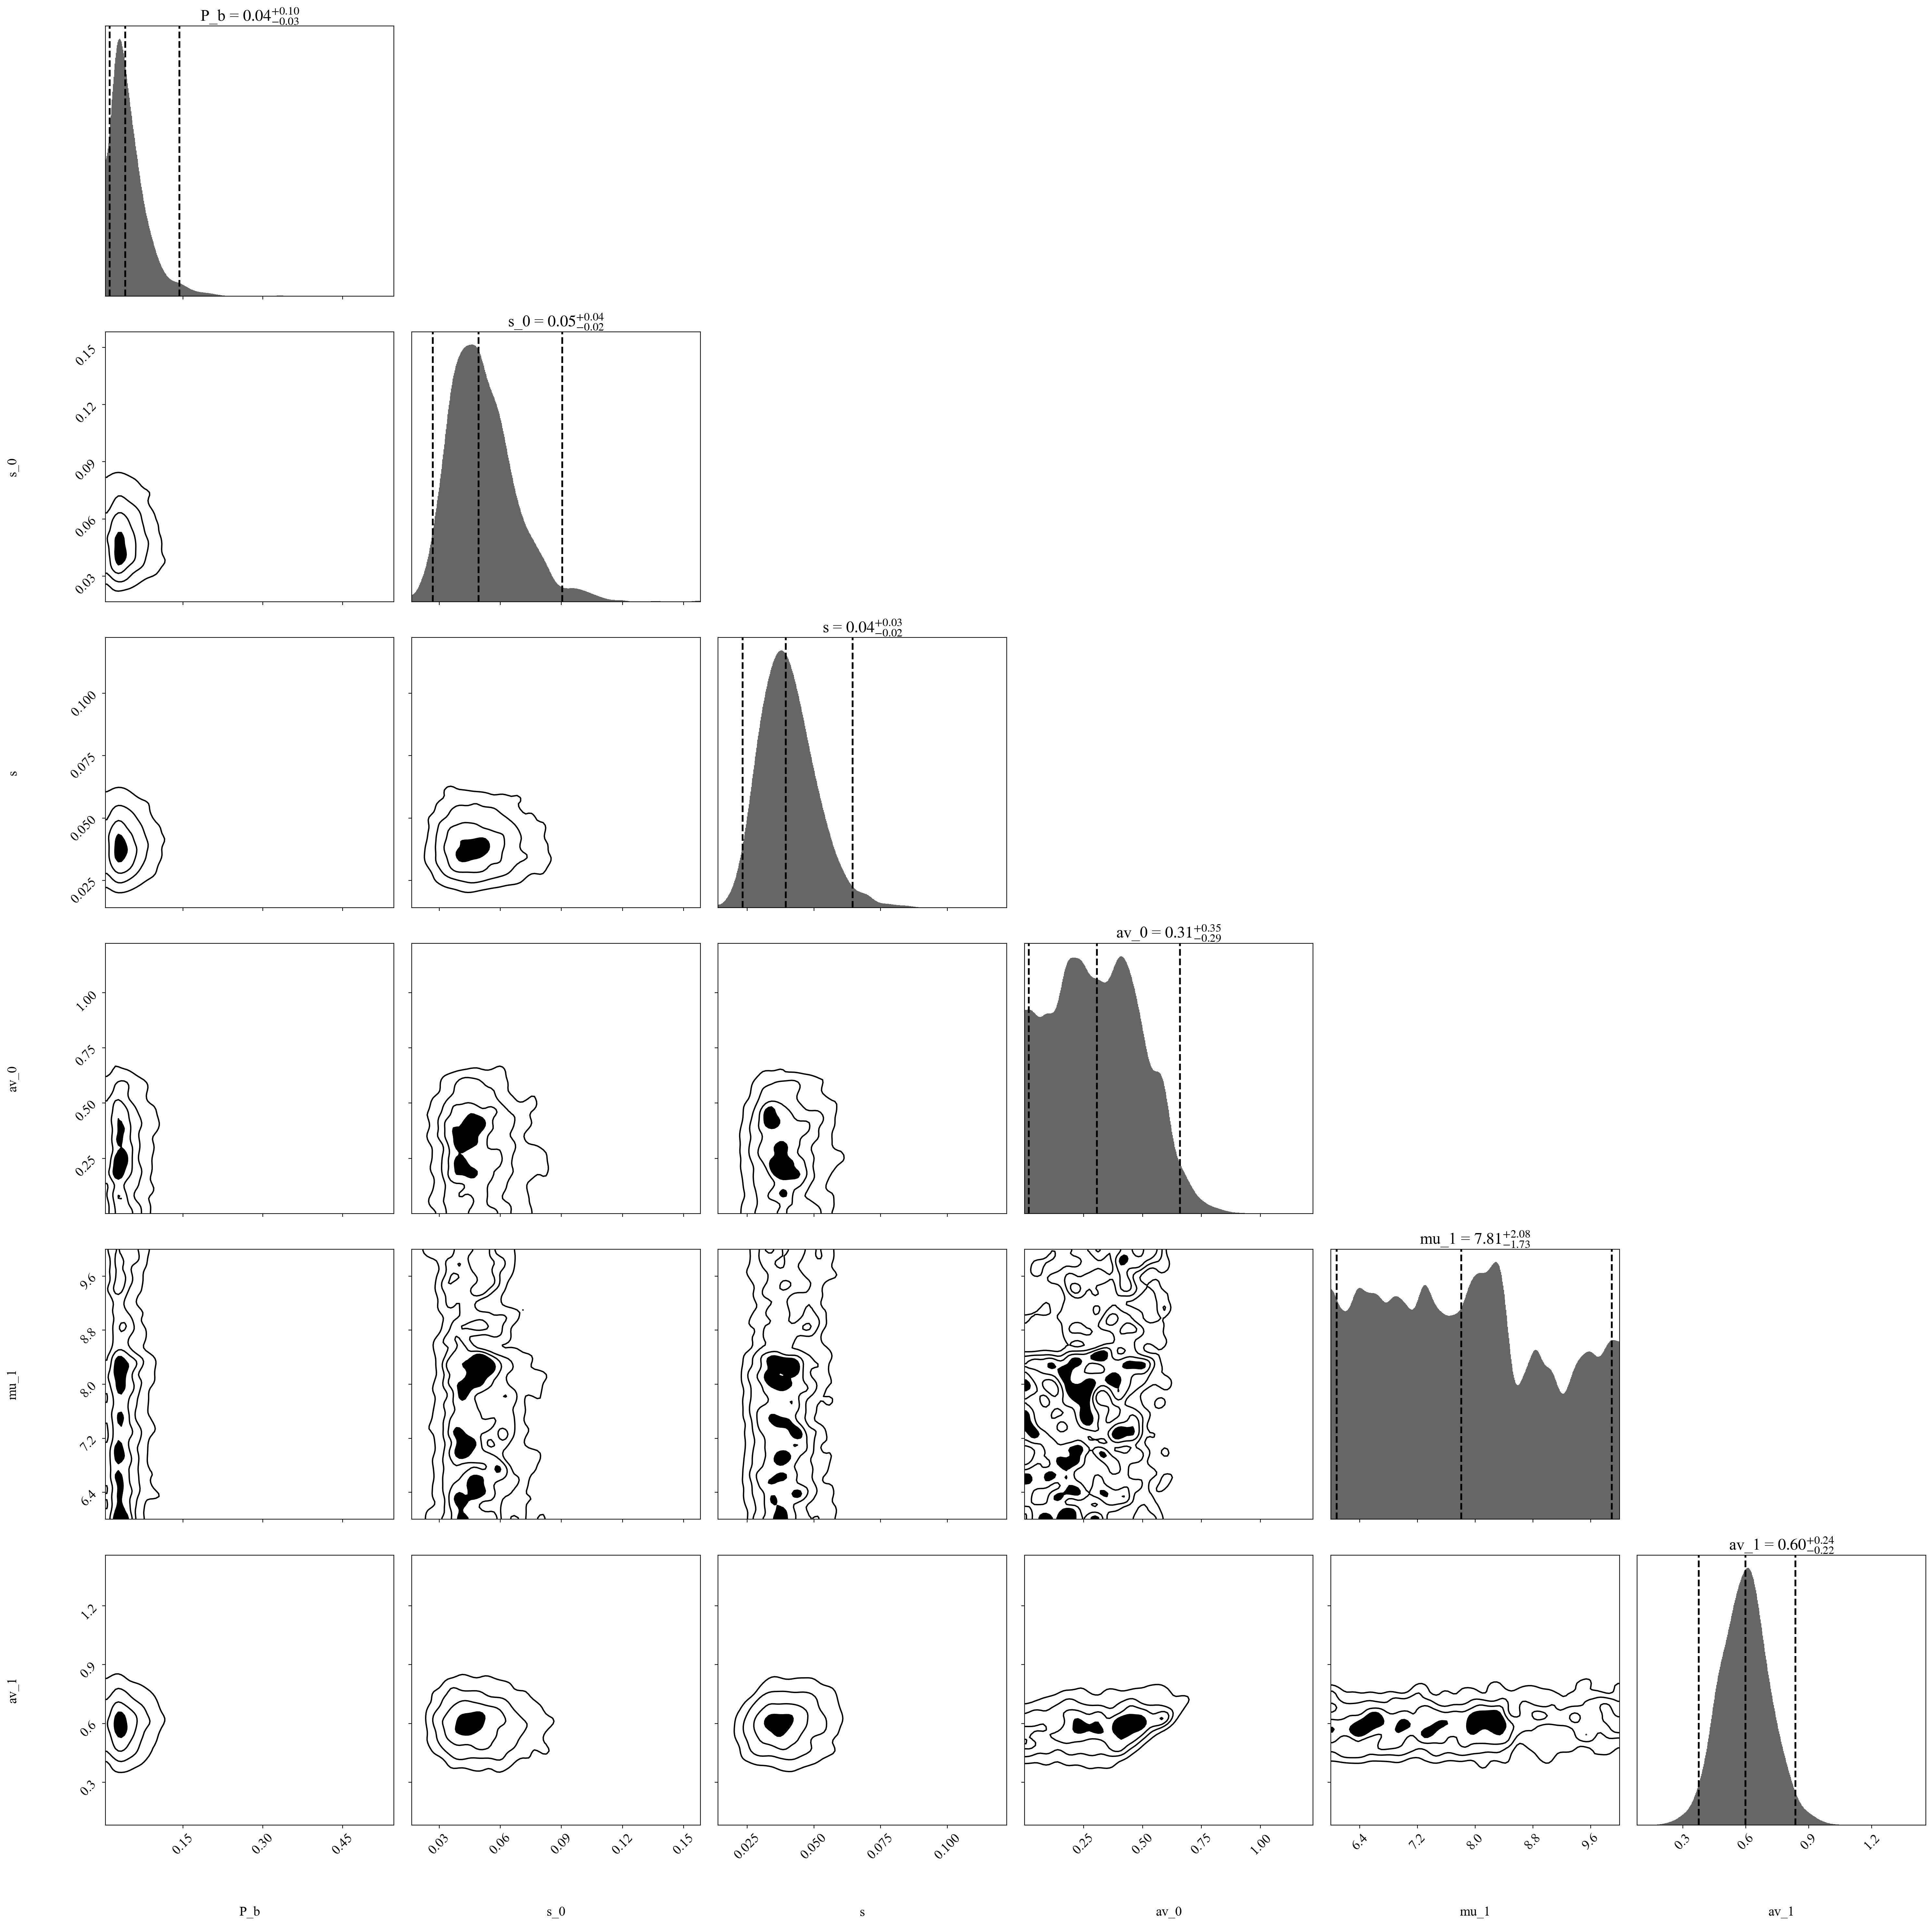

In [26]:
fig2, axes = dyplot.cornerplot(res, 
                                labels=['P_b', 's_0', 's', 'av_0', 'mu_1', 'av_1'], # p_b: portion of outliers
                                show_titles=True,
                                fig=plt.subplots(6, 6, figsize=(30, 30)))
fig2.tight_layout()

In [35]:
np.sum(pdfbin[emission_mask, :, :], axis=0).shape, x_max0.shape, y_max[emission_mask].shape, pdfbin[emission_mask, :, :].shape

((750, 300), (9,), (9,), (9, 750, 300))

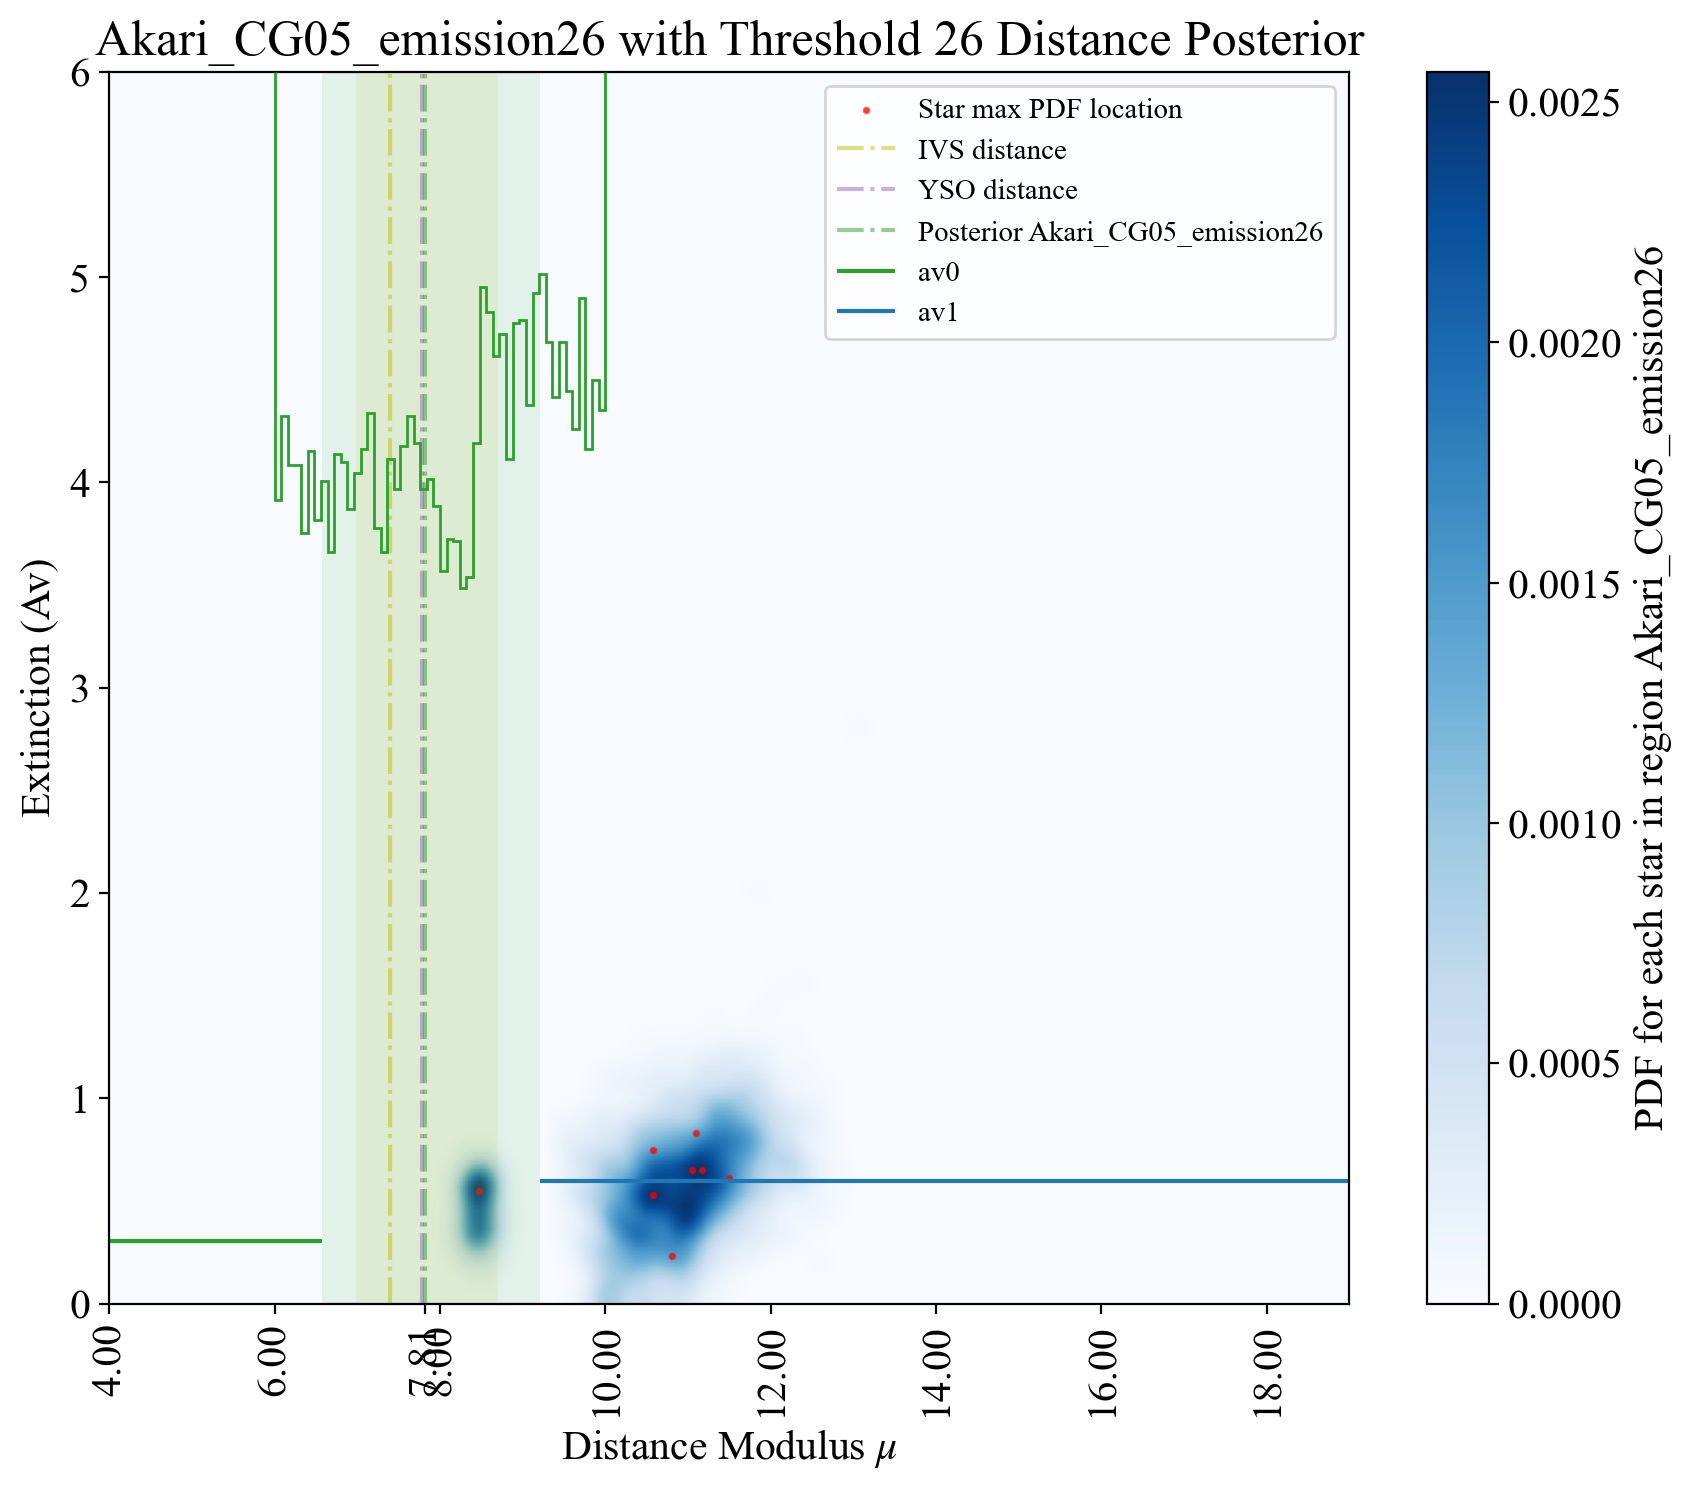

In [27]:
weights = np.exp(res.logwt - res.logz[-1])
samples_equal = dynesty.utils.resample_equal(res.samples, weights)
av0 = samples_equal[:, 3]
mu_samples = samples_equal[:, 4]
av1 = samples_equal[:, 5]

# --- Plot 1: Av vs Mu with posterior ---
fig1, ax1 = plt.subplots(figsize=(10, 8))# Prepare the plot
# Set axis labels
ax1.set_xlabel('Distance Modulus $\mu$')
ax1.set_ylabel('Extinction (Av)')
im = ax1.imshow(np.sum(pdfbin[emission_mask, :, :], axis=0).T, aspect='auto', cmap='Blues', interpolation=None, origin='lower', 
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                # vmin=0, vmax=0.08
                )
ax1.scatter(x_max0, y_max[emission_mask], color='red', s=3, alpha=0.6, label='Star max PDF location')
ax1.axvline(7.4, c='y', alpha=0.5, ls='-.', label='IVS distance')
ax1.axvspan(6.98, 8.7, facecolor='y', alpha=0.1)
ax1.axvline(5*np.log10(359)-5, c='C4' , alpha = 0.5, ls = '-.', label = 'YSO distance')
# fitted distance modulus:
ax1.axvspan(np.quantile(mu_samples, 0.16),  np.quantile(mu_samples, 0.84), facecolor='C2', alpha=0.1)
ax1.axvline(np.quantile(mu_samples, 0.5), c='C2', alpha=0.5, ls='-.', label = f'Posterior {region_name}')

ax1.hlines(y = np.quantile(av0, 0.5), xmin=4, xmax = np.quantile(mu_samples, 0.16), label = 'av0', colors= 'C2')
ax1.hlines(y = np.quantile(av1, 0.5),xmin=np.quantile(mu_samples, 0.84), xmax = 19, label = 'av1')
# dist_tick_locations = sorted(np.concatenate((np.arange(4,20, 2), [np.quantile(mu_samples, 0.16), np.quantile(mu_samples, 0.5), np.quantile(mu_samples, 0.84)])))
dist_tick_locations = sorted(np.concatenate((np.arange(4,20, 2), [ np.quantile(mu_samples, 0.5)])))

ax1.set_title(f'{region_name} with Threshold {em_val} Distance Posterior')
ax1.set_xticks(dist_tick_locations)
ax1.tick_params(axis='x', labelrotation=90)
cbar = fig1.colorbar(im, ax=ax1)
cbar.set_label(f'PDF for each star in region {region_name}')
ax1.legend(fontsize='x-small')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Inset upside-down histogram INSIDE the main axes ---
ax_hist = inset_axes(
    ax1,
    width="100%",
    height="100%",          # keep this at 100%
    loc="upper left",
    bbox_to_anchor=(0, 0.56, 1, 0.44),  # taller inset (44% of ax1)
    bbox_transform=ax1.transAxes,
    borderpad=0
)

ax_hist.set_facecolor('none')
ax_hist.patch.set_alpha(0)
ax_hist.hist(
    mu_samples,
    bins=50,
    histtype='step',
    density=True,
    color='C2'
)

# Posterior markers
# ax_hist.axvspan(
#     np.quantile(mu_samples, 0.16),
#     np.quantile(mu_samples, 0.84),
#     color='C2',
#     alpha=0.2
# )
# ax_hist.axvline(np.quantile(mu_samples, 0.5), c='C2', ls='--')

# Flip histogram upside-down
ax_hist.invert_yaxis()
# EXACT same x-axis
ax_hist.set_xlim(ax1.get_xlim())
# Clean look
ax_hist.set_xticks([])
ax_hist.set_yticks([])
for spine in ['right', 'top', 'left', 'bottom']:
    ax_hist.spines[spine].set_visible(False)

# ax_hist.set_ylabel('Posterior', fontsize=9)


# fig1.tight_layout()
# fig1.savefig(f"{plot_path}/{region_name}_av_vs_mu_star_threshold{em_val}posteriors.png", dpi=300)
# plt.close(fig1)

In [170]:
np.quantile(mu_samples, 0.5), np.quantile(mu_samples, 0.16),  np.quantile(mu_samples, 0.84),5*np.log10(359)-5,

(8.783228885431809, 8.671179934442108, 9.002714557295448, 7.775472242891597)

## Use Planck dust map to filter out the background stars (for big CG)

In [ ]:
from astropy.coordinates import SkyCoord
from dustmaps.planck import PlanckQuery
cg30_31_back = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/CG31/backup_old_files/CG30_CG31_CG31back_decaps2MassGaia_crossmatched.csv')
cg30_31_back_mdwarf = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/CG30_CG31_CG31back_cut078_22_Mdwarf_res.csv')

In [ ]:
cg30_31_back_star_2d = SkyCoord(ra = cg30_31_back['ra'], dec = cg30_31_back['dec'], frame = 'icrs', unit = 'deg')
cg30_31_back_mdwarf2d = SkyCoord(ra = cg30_31_back_mdwarf['ra'], dec=cg30_31_back_mdwarf['dec'], frame = 'icrs', unit = 'deg')

## Add Akari for smaller region

In [ ]:
from astropy.wcs import WCS
from astropy import units as u
from astropy.io import fits
import matplotlib.pyplot as plt

In [ ]:
akari = fits.open('/Users/anniegao/Documents/CG_mapping_files/Akari/l135.12_b-55.00_ecl_6deg_N160_fixstripe.fits')[0]
wcs = WCS(akari.header)

Text(0.5, 1.0, 'Akari 160 μm')

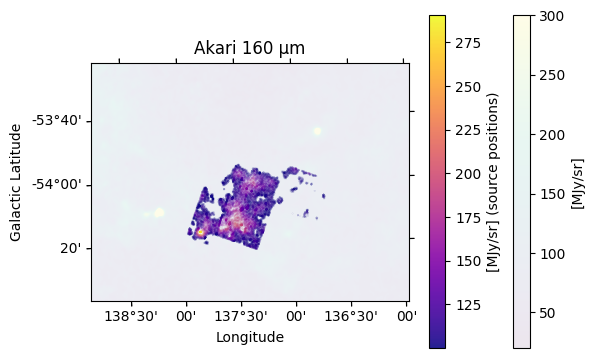

In [ ]:
x_pixel, y_pixel = wcs.world_to_pixel_values(cg30_31_back['elon'], cg30_31_back['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
emission = akari.data[y,x]
mask = emission> 100
a_sel, b_sel = x_pixel[mask], y_pixel[mask]
emission_sel = emission[mask]
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))

im = ax.imshow(akari.data, origin='lower', vmin=20, vmax=300, alpha=0.1)
sc = plt.scatter(x = a_sel, y = b_sel, s=0.001, c=emission_sel,cmap='plasma', alpha=0.9) 
ax.set(xlabel='Longitude', ylabel='Galactic Latitude')
ax.set_xlim(200, 600)
ax.set_ylim(800, 1100)

cbar = plt.colorbar(im, shrink=0.9)
cbar.set_label('[MJy/sr]')
cbar2 = plt.colorbar(sc, ax=ax, shrink=0.9)
cbar2.set_label('[MJy/sr] (source positions)')
ax.set_title('Akari 160 μm')

In [ ]:
region_name = 'Akari_CG3031_emission100_cut22'
# cg30_31_back[mask].to_csv(f'/Users/anniegao/Documents/CG_mapping_files/1-queried_stars/{region_name}.csv', index= False)

In [ ]:
# data_queried = pd.read_csv(f'/Users/anniegao/Documents/CG_mapping_files/1-queried_stars/{region_name}.csv')
data_queried = cg30_31_back[mask]
merged_table_selected, parallax, parallax_err = fit_wo_Mdwarf(data_queried, base, region_name) #

DECam_g (0.0%)
DECam_r (-4.0%)
DECam_i (-5.0%)
DECam_z (-4.0%)
DECam_Y (-5.0%)
2MASS_J (-2.0%)
2MASS_H (4.0%)
2MASS_Ks (3.0%)
Reading filter 2MASS_Ks           
/Users/anniegao/Documents/Research/Cometary_Globules/pipeline.py:245: RuntimeWarning: divide by zero encountered in log10
  mag_decam = -2.5*np.log10(flux_decam)
/Users/anniegao/Documents/Research/Cometary_Globules/pipeline.py:245: RuntimeWarning: invalid value encountered in log10
  mag_decam = -2.5*np.log10(flux_decam)
/Users/anniegao/Documents/Research/Cometary_Globules/pipeline.py:246: RuntimeWarning: invalid value encountered in divide
  magerr_decam = 1.086*flux_decam_err/flux_decam
Fitting object 8157/8157 [chi2/n: 0.2/5] (mean time: 1.149 s/obj, est. time remaining:      0.000 s)    


Fitted result saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG3031_emission100_cut22.h5
Selected Mdwarf table saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/Akari_CG3031_emission100_cut22_allstar.csv
Saved modified parallax and parallax_err too.


In [ ]:
filename = f'{base}2-star_modeling/output/'

# selected_table = pd.read_csv(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_Mdwarf.csv")

f = h5py.File('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG3031_emission100_cut22.h5', 'r')
chi2_mist =f['obj_chi2min'] #best fit chi2
nbands_mist = f['obj_Nbands']# number of bands in fit
dists_mist = f['samps_dist'] # distance samples
reds_mist = f['samps_red'] # A(V) samples
dreds_mist = f['samps_dred']# R(V) samples
good=(stats.chi2.sf(chi2_mist, nbands_mist) > 0.01)
dists_mist = np.array(dists_mist)[good, :]
reds_mist = np.array(reds_mist)[good, :]
dreds_mist = np.array(dreds_mist)[good, :]

plx_data = np.load(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_parallax.npz")
parallax, parallax_err = plx_data['parallax'], plx_data['parallax_err']
pdfbin, xedges, yedges = brutus.pdf.bin_pdfs_distred((dists_mist, reds_mist, dreds_mist), 
                                                    parallaxes = parallax,  # limits smoothing
                                                    parallax_errors=parallax_err,  # if parallax SNR is high
                                                    #  avlim=(0., 4.5),
                                                    )
N_stars = pdfbin.shape[0]
max_positions = np.argmax(pdfbin.reshape(N_stars, -1), axis=1)
x_idx, y_idx = np.unravel_index(max_positions, (750, 300))  # shape: (N_stars,)
x_centers = 0.5 * (xedges[:-1] + xedges[1:])  # shape: (750,)
y_centers = 0.5 * (yedges[:-1] + yedges[1:])  # shape: (300,)
x_max = x_centers[x_idx] # want to choose x_max<10.5 to avoid the second distance reference
y_max = y_centers[y_idx]
plot_path = '/Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/plots'
np.savez(f"{plot_path}/{region_name}_individual_star_samples.npz",
        good=good,
        x_max=x_max,
        y_max=y_max,
        xedges=xedges,
        yedges=yedges,
        pdfbin = pdfbin)

In [ ]:
pd_merged = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/Akari_CG3031_emission100_cut22_allstar.csv')[good]
pd_merged['derived_dist'] = 10**( x_max/5 +1)
pd_merged['derived Av'] = y_max
x_pixel, y_pixel = wcs.world_to_pixel_values(pd_merged['elon'], pd_merged['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
emission = akari.data[y,x]
pd_merged['AKARI_emission_MJy_sr-1'] = emission
pd_merged.to_csv(f'{base}2-star_modeling/M_dwarf_fit_results/{region_name}_allstar_res.csv', index= False)

### Different emission and region combination

In [ ]:
f = h5py.File('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG3031_emission100_cut22.h5', 'r')

In [ ]:
dists_mist0 = dists_mist
reds_mist0 = reds_mist
x_max0 = x_max

In [ ]:
em_val = 140
emission_mask = (emission> em_val)&(pd_merged['obj_id'].isin(cg30_31_back_mdwarf['obj_id']))
dists_mist = dists_mist0[emission_mask]
reds_mist = reds_mist0[emission_mask] 
x_max = x_max0[emission_mask]

In [ ]:
# convert from kpc to distance modulus, add limit of 10 distance modulus to avoid confusion
dist_mist_new = dists_mist[x_max<10.5]
red_mist_new = reds_mist[x_max<10.5]
dms_mist = 5. * np.log10(dist_mist_new) + 10
nclouds = 1  # number of clouds
ndim = 2 * nclouds + 4  # number of parameters

# adjust default distance modulus limits in ptform
ptform_kwargs = {'dlims': (6., 10.)}

# distances and extinctions to be passed to loglike
logl_args = [dms_mist, red_mist_new]
logl_kwargs = {'monotonic': True}  # extinctions must increase

# fit dust along the LOS with dynesty
sampler = dynesty.NestedSampler(loglike, ptform, ndim,
                                ptform_kwargs=ptform_kwargs,
                                logl_args=logl_args,
                                # logl_kwargs=logl_kwargs
                                )
sampler.run_nested(dlogz=0.01)
# save results
res = sampler.results

9308it [02:34, 60.33it/s, +500 | bound: 285 | nc: 1 | ncall: 232995 | eff(%):  4.219 | loglstar:   -inf < -20.448 <    inf | logz: -34.440 +/-  0.137 | dlogz:  0.000 >  0.010]


In [ ]:
with open(f'{base}3-nested_sampling/results/{region_name}threshold{em_val}_Mdwarf_nested_sampling_res.pkl', 'wb') as f:
    pickle.dump(res, f)
print(f'Nested Sampling result saved to {base}3-nested_sampling/results/{region_name}threshold{em_val}_Mdwarf_nested_sampling_res.pkl')


Nested Sampling result saved to /Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/results/Akari_CG3031_emission100_cut22threshold140_Mdwarf_nested_sampling_res.pkl


In [ ]:
# sum(cg30_31_back_mdwarf[cg30_31_back_mdwarf['derived_dist']< 1000]['obj_id'].isna())
pd_merged = pd.read_csv(f'{base}2-star_modeling/M_dwarf_fit_results/{region_name}_allstar_res.csv')
# .iloc[emission_mask, :]

In [ ]:
mu_samples = res.samples[:, 4]

# --- Plot 1: Av vs Mu with posterior ---
fig1, ax1 = plt.subplots(figsize=(10, 8))# Prepare the plot
# Set axis labels
ax1.set_xlabel('Distance Modulus $\mu$')
ax1.set_ylabel('Extinction (Av)')
im = ax1.imshow(np.sum(pdfbin[emission_mask, :, :], axis=0).T, aspect='auto', cmap='Blues', interpolation=None, origin='lower', 
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                # vmin=0, vmax=0.08
                )
ax1.scatter(x_max, y_max[emission_mask], color='red', s=3, alpha=0.6, label='Star max PDF location')
ax1.axvline(7.4, c='y', alpha=0.5, ls='-.', label='IVS distance')
ax1.axvspan(6.98, 8.7, facecolor='y', alpha=0.1)
ax1.axvline(5*np.log10(359)-5, c='C4' , alpha = 0.5, ls = '-.', label = 'YSO distance')
# fitted distance modulus:
ax1.axvspan(np.quantile(mu_samples, 0.16),  np.quantile(mu_samples, 0.84), facecolor='C2', alpha=0.1)
ax1.axvline(np.quantile(mu_samples, 0.5), c='C2', alpha=0.5, ls='-.', label = f'Posterior {region_name} $\mu \pm \sigma$')

dist_tick_locations = sorted(np.concatenate((np.arange(4,20, 2), [np.quantile(mu_samples, 0.16), np.quantile(mu_samples, 0.5), np.quantile(mu_samples, 0.84)])))

ax1.set_title(f'Mdwarf pdf and {region_name} with Threshold {em_val} Distance Posterior')
ax1.set_xticks(dist_tick_locations)
ax1.tick_params(axis='x', labelrotation=90)
cbar = fig1.colorbar(im, ax=ax1)
cbar.set_label(f'PDF for each star in region {region_name}')
ax1.legend()
# fig1.tight_layout()
# fig1.savefig(f"{plot_path}/{region_name}_av_vs_mu_star_threshold{em_val}posteriors.png", dpi=300)
# plt.close(fig1)


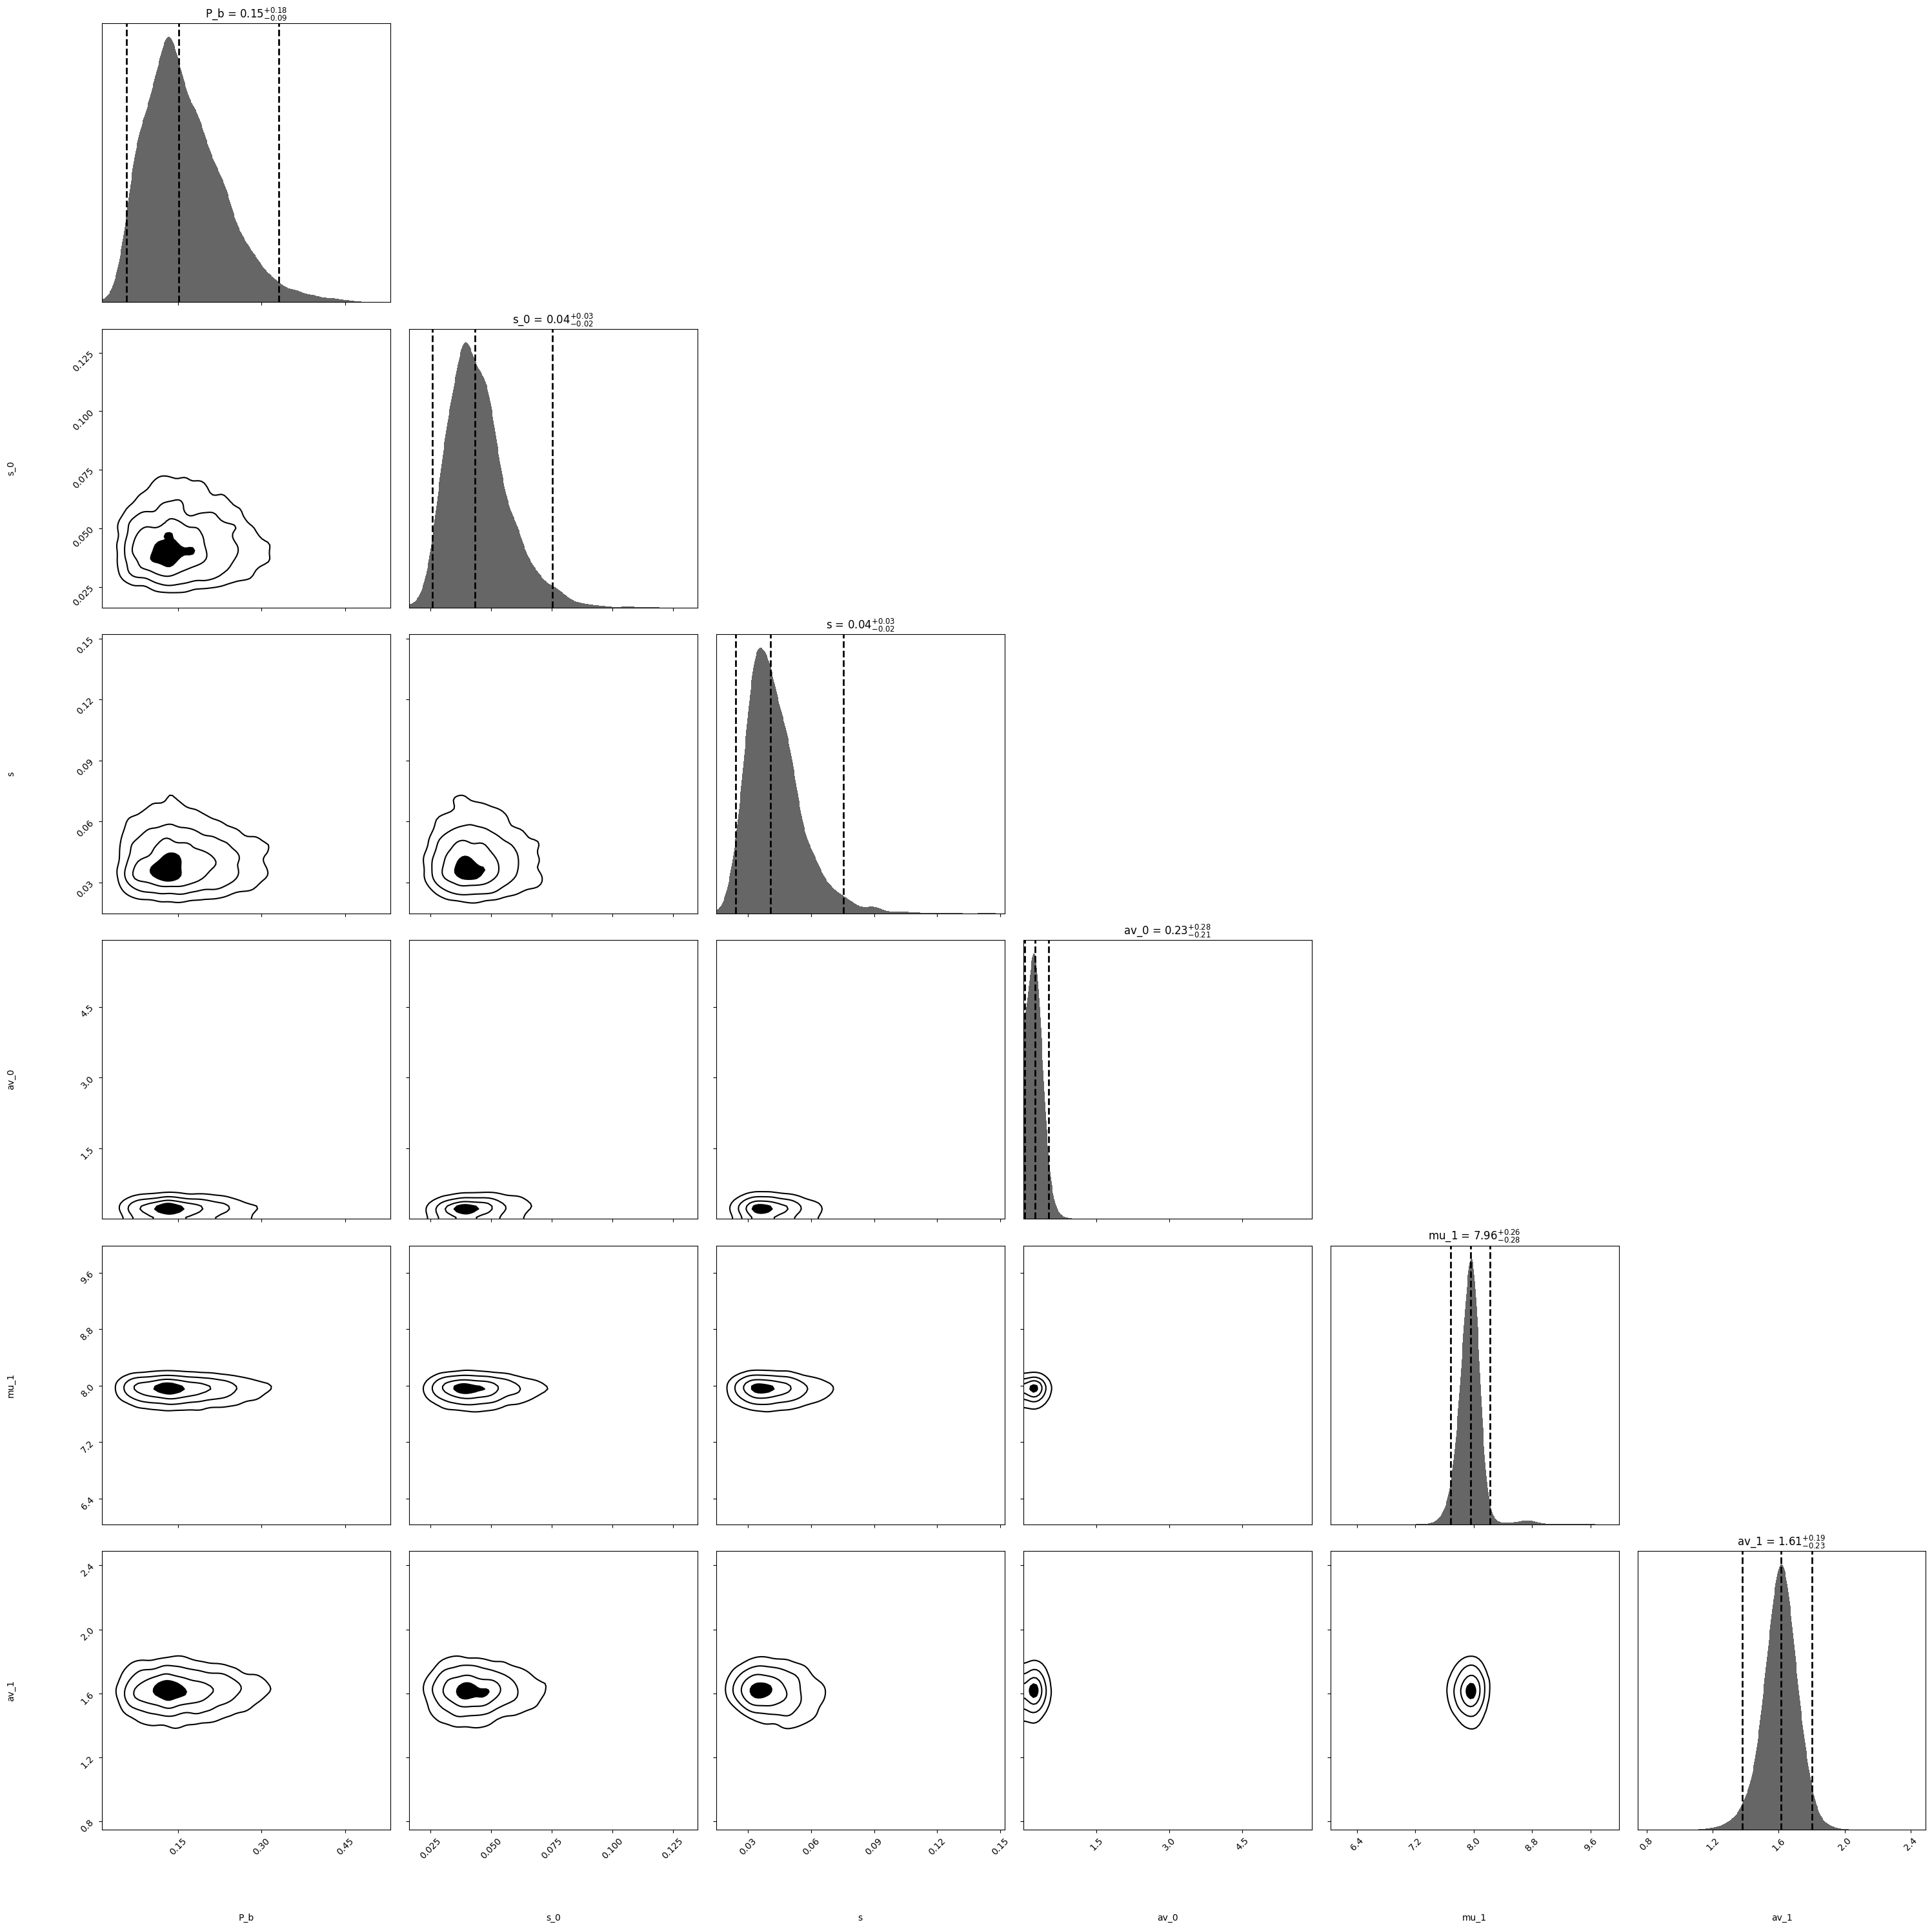

In [ ]:
fig2, axes = dyplot.cornerplot(res, 
                                labels=['P_b', 's_0', 's', 'av_0', 'mu_1', 'av_1'], # p_b: portion of outliers
                                show_titles=True,
                                fig=plt.subplots(6, 6, figsize=(30, 30)))
fig2.tight_layout()
fig2.savefig(f"{plot_path}/{region_name}_threshold{em_val}_corner_plot.png", dpi=300)


## CG22

In [ ]:
akari22 = fits.open('/Users/anniegao/Documents/CG_mapping_files/Akari/CG22_l140.02_b-50.00_ecl_6deg_N160_fixstripe.fits')[0]
wcs = WCS(akari22.header)
cg22 = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/1-queried_stars/CG22_B1_decaps_2mass_gaia.csv')
cg22_mdwarf = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/CG22_B1_Mdwarf_res.csv')

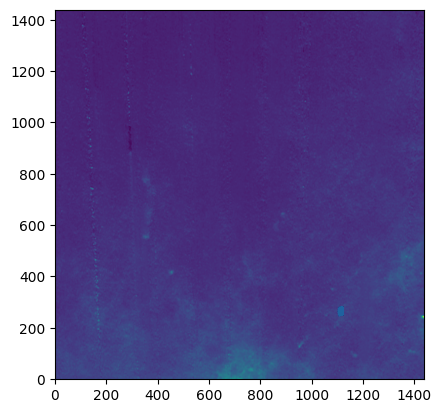

In [ ]:
akari27 = fits.open('/Users/anniegao/Downloads/AKARIImages-6/l140.02_b-50.00_ecl_6deg_N160_fixstripe.fits')[0]
wcs27 = WCS(akari27.header)
cg27 = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/1-queried_stars/CG27_decaps_2mass_gaia.csv')
x24_pixel, y24_pixel = wcs27.world_to_pixel_values(cg27['elon'], cg27['elat'])

plt.imshow(akari27.data, origin='lower',alpha=1)
plt.scatter(x = x24_pixel, y = y24_pixel, s=0.001,cmap='plasma', alpha=1) 


Text(0.5, 1.0, 'akari22 160 μm')

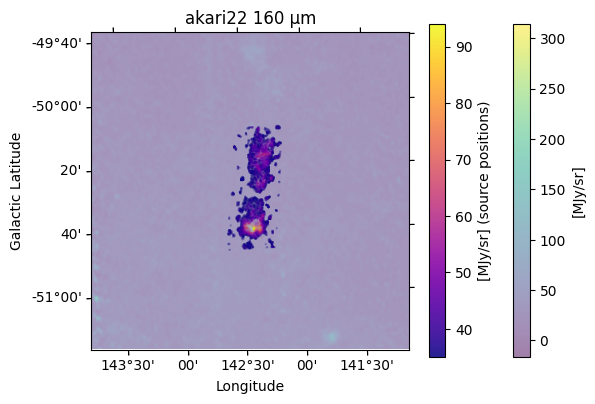

In [ ]:
x_pixel, y_pixel = wcs.world_to_pixel_values(cg22['elon'], cg22['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
emission = akari22.data[y,x]
mask = emission> 35
a_sel, b_sel = x_pixel[mask], y_pixel[mask]
emission_sel = emission[mask]
fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))

im = ax.imshow(akari22.data, origin='lower',alpha=0.5)
sc = plt.scatter(x = a_sel, y = b_sel, s=0.001, c=emission_sel,cmap='plasma', alpha=0.9) 
ax.set(xlabel='Longitude', ylabel='Galactic Latitude')
ax.set_xlim(150, 550)
ax.set_ylim(400, 800)

cbar = plt.colorbar(im, shrink=0.9)
cbar.set_label('[MJy/sr]')
cbar2 = plt.colorbar(sc, ax=ax, shrink=0.9)
cbar2.set_label('[MJy/sr] (source positions)')
ax.set_title('akari22 160 μm')

In [ ]:
region_name = 'Akari_CG22_emission30_cut22'
data_queried = cg22[mask]
merged_table_selected, parallax, parallax_err = fit_wo_Mdwarf(data_queried, base, region_name) #

DECam_g (0.0%)
DECam_r (-4.0%)
DECam_i (-5.0%)
DECam_z (-4.0%)
DECam_Y (-5.0%)
2MASS_J (-2.0%)
2MASS_H (4.0%)
2MASS_Ks (3.0%)
Reading filter 2MASS_Ks           
Fitting object 4899/4899 [chi2/n: 0.4/5] (mean time: 0.739 s/obj, est. time remaining:      0.000 s)    


Fitted result saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG22_emission30_cut22.h5
Selected Mdwarf table saved to /Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/Akari_CG22_emission30_cut22_allstar.csv
Saved modified parallax and parallax_err too.


In [ ]:
filename = f'{base}2-star_modeling/output/'

# selected_table = pd.read_csv(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_Mdwarf.csv")

f = h5py.File('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/output/Akari_CG22_emission30_cut22.h5', 'r')
chi2_mist =f['obj_chi2min'] #best fit chi2
nbands_mist = f['obj_Nbands']# number of bands in fit
dists_mist = f['samps_dist'] # distance samples
reds_mist = f['samps_red'] # A(V) samples
dreds_mist = f['samps_dred']# R(V) samples
good=(stats.chi2.sf(chi2_mist, nbands_mist) > 0.01)
dists_mist = np.array(dists_mist)[good, :]
reds_mist = np.array(reds_mist)[good, :]
dreds_mist = np.array(dreds_mist)[good, :]

# plx_data = np.load(f"{base}2-star_modeling/M_dwarf_fit_results/{region_name}_parallax.npz")
# parallax, parallax_err = plx_data['parallax'], plx_data['parallax_err']
pdfbin, xedges, yedges = brutus.pdf.bin_pdfs_distred((dists_mist, reds_mist, dreds_mist), 
                                                    parallaxes = parallax,  # limits smoothing
                                                    parallax_errors=parallax_err,  # if parallax SNR is high
                                                    #  avlim=(0., 4.5),
                                                    )
N_stars = pdfbin.shape[0]
max_positions = np.argmax(pdfbin.reshape(N_stars, -1), axis=1)
x_idx, y_idx = np.unravel_index(max_positions, (750, 300))  # shape: (N_stars,)
x_centers = 0.5 * (xedges[:-1] + xedges[1:])  # shape: (750,)
y_centers = 0.5 * (yedges[:-1] + yedges[1:])  # shape: (300,)
x_max = x_centers[x_idx] # want to choose x_max<10.5 to avoid the second distance reference
y_max = y_centers[y_idx]
plot_path = '/Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/plots'
np.savez(f"{plot_path}/{region_name}_individual_star_samples.npz",
        good=good,
        x_max=x_max,
        y_max=y_max,
        xedges=xedges,
        yedges=yedges,
        pdfbin = pdfbin)

In [ ]:
pd_merged = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/M_dwarf_fit_results/Akari_CG22_emission30_cut22_allstar.csv')[good]
pd_merged['derived_dist'] = 10**( x_max/5 +1)
pd_merged['derived Av'] = y_max
x_pixel, y_pixel = wcs.world_to_pixel_values(pd_merged['elon'], pd_merged['elat'])
x, y = x_pixel.astype(int), y_pixel.astype(int)
emission = akari.data[y,x]
pd_merged['AKARI_emission_MJy_sr-1'] = emission
# pd_merged.to_csv(f'{base}2-star_modeling/M_dwarf_fit_results/{region_name}_allstar_res.csv', index= False)

In [ ]:
dists_mist0 = dists_mist
reds_mist0 = reds_mist
x_max0 = x_max

In [ ]:
em_val = 35
emission_mask = (emission> em_val)&(pd_merged['obj_id'].isin(cg22_mdwarf['obj_id']))
dists_mist = dists_mist0[emission_mask]
reds_mist = reds_mist0[emission_mask] 
x_max = x_max0[emission_mask]

In [ ]:
# convert from kpc to distance modulus, add limit of 10 distance modulus to avoid confusion
dist_mist_new = dists_mist[x_max<10.5]
red_mist_new = reds_mist[x_max<10.5]
dms_mist = 5. * np.log10(dist_mist_new) + 10
nclouds = 1  # number of clouds
ndim = 2 * nclouds + 4  # number of parameters

# adjust default distance modulus limits in ptform
ptform_kwargs = {'dlims': (6., 10.)}

# distances and extinctions to be passed to loglike
logl_args = [dms_mist, red_mist_new]
logl_kwargs = {'monotonic': True}  # extinctions must increase

# fit dust along the LOS with dynesty
sampler = dynesty.NestedSampler(loglike, ptform, ndim,
                                ptform_kwargs=ptform_kwargs,
                                logl_args=logl_args,
                                # logl_kwargs=logl_kwargs
                                )
sampler.run_nested(dlogz=0.01)
# save results
res = sampler.results

9656it [01:14, 129.92it/s, +500 | bound: 193 | nc: 1 | ncall: 162619 | eff(%):  6.265 | loglstar:   -inf < -24.695 <    inf | logz: -39.382 +/-  0.142 | dlogz:  0.000 >  0.010]


In [ ]:
with open(f'{base}3-nested_sampling/results/{region_name}threshold{em_val}_Mdwarf_nested_sampling_res.pkl', 'wb') as f:
    pickle.dump(res, f)
print(f'Nested Sampling result saved to {base}3-nested_sampling/results/{region_name}threshold{em_val}_Mdwarf_nested_sampling_res.pkl')


Nested Sampling result saved to /Users/anniegao/Documents/CG_mapping_files/3-nested_sampling/results/Akari_CG22_emission30_cut22threshold35_Mdwarf_nested_sampling_res.pkl


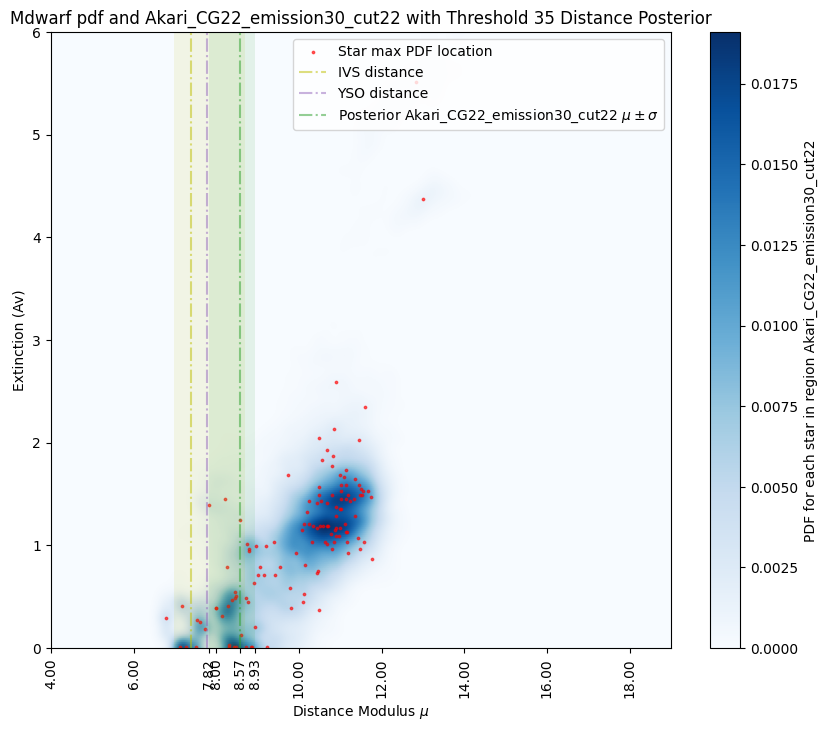

In [ ]:
mu_samples = res.samples[:, 4]

# --- Plot 1: Av vs Mu with posterior ---
fig1, ax1 = plt.subplots(figsize=(10, 8))# Prepare the plot
# Set axis labels
ax1.set_xlabel('Distance Modulus $\mu$')
ax1.set_ylabel('Extinction (Av)')
im = ax1.imshow(np.sum(pdfbin[emission_mask, :, :], axis=0).T, aspect='auto', cmap='Blues', interpolation=None, origin='lower', 
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                # vmin=0, vmax=0.08
                )
ax1.scatter(x_max, y_max[emission_mask], color='red', s=3, alpha=0.6, label='Star max PDF location')
ax1.axvline(7.4, c='y', alpha=0.5, ls='-.', label='IVS distance')
ax1.axvspan(6.98, 8.7, facecolor='y', alpha=0.1)
ax1.axvline(5*np.log10(359)-5, c='C4' , alpha = 0.5, ls = '-.', label = 'YSO distance')
# fitted distance modulus:
ax1.axvspan(np.quantile(mu_samples, 0.16),  np.quantile(mu_samples, 0.84), facecolor='C2', alpha=0.1)
ax1.axvline(np.quantile(mu_samples, 0.5), c='C2', alpha=0.5, ls='-.', label = f'Posterior {region_name} $\mu \pm \sigma$')

dist_tick_locations = sorted(np.concatenate((np.arange(4,20, 2), [np.quantile(mu_samples, 0.16), np.quantile(mu_samples, 0.5), np.quantile(mu_samples, 0.84)])))

ax1.set_title(f'Mdwarf pdf and {region_name} with Threshold {em_val} Distance Posterior')
ax1.set_xticks(dist_tick_locations)
ax1.tick_params(axis='x', labelrotation=90)
cbar = fig1.colorbar(im, ax=ax1)
cbar.set_label(f'PDF for each star in region {region_name}')
ax1.legend()
# fig1.tight_layout()
# fig1.savefig(f"{plot_path}/{region_name}_av_vs_mu_star_threshold{em_val}posteriors.png", dpi=300)
# plt.close(fig1)


In [10]:
from __future__ import print_function, division
from six.moves import range
import dynesty
import os
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import h5py
import brutus
import sys
import glob
# from dl import queryClient as qc
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy import units as u
from astroquery.xmatch import XMatch
from astroquery.gaia import Gaia
from astropy.table import Table, join,vstack
from astropy.io import fits

from brutus import filters
from brutus.utils import inv_magnitude
from brutus import fitting
from brutus.los import LOS_clouds_priortransform as ptform
from brutus.los import LOS_clouds_loglike_samples as loglike
from zero_point import zpt
from dynesty import plotting as dyplot


In [84]:
cg_stars = pd.read_csv('/Users/anniegao/Documents/CG_mapping_files/CG31/CG31_selected.csv')
pd_merged = cg_stars

In [85]:
pd_merged.shape, cg_stars.shape

((20301, 410), (20301, 410))

In [86]:
filename = f'{base}2-star_modeling/output/'
merr_max=0.25
filt = filters.decam[1:] + filters.tmass[:] #+ filters.vista[2:] #+filters.gaia[:]
# zero points
zp_mist = brutus.utils.load_offsets('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/offsets_mist_v9.txt',filters=filt)
# import MIST model grid
gridfile = '/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/grid_mist_v10.h5'
(models_mist, labels_mist, lmask_mist) = brutus.utils.load_models(gridfile, filters=filt)
BF_mist = fitting.BruteForce(models_mist, labels_mist, lmask_mist)
#load tables for parallax zeropoint correction
zpt.load_tables()
# dist_select = pd_merged[~((pd_merged['Plx']< 1000/600)|(pd_merged['Plx']>1000/200))]
pd_merged = Table.from_pandas(pd_merged)
flux_decam = np.c_[pd_merged['mean_g'].value, pd_merged['mean_r'].value, pd_merged['mean_i'].value, pd_merged['mean_z'].value, pd_merged['mean_y'].value]
flux_decam_err = np.c_[pd_merged['err_g'].value, pd_merged['err_r'].value, pd_merged['err_i'].value,pd_merged['err_z'].value, pd_merged['err_y'].value]
mag_2mass =  np.c_[pd_merged['j_m'].value, pd_merged['h_m'].value, pd_merged['k_m'].value ] #pd_merged['Gmag'], pd_merged['BPmag'], pd_merged['RPmag'],
magerr_2mass = np.c_[pd_merged['j_msigcom'].value, pd_merged['h_msigcom'].value, pd_merged['k_msigcom'].value]  #pd_merged['e_Gmag'], pd_merged['e_BPmag'], pd_merged['e_RPmag'],
mag_decam = -2.5*np.log10(flux_decam)
magerr_decam = 1.086*flux_decam_err/flux_decam
# stack magnitudes and error
mag = np.c_[mag_decam[:], mag_2mass[:]]
mag_err = np.c_[magerr_decam[:], magerr_2mass[:]]
#add 0.02 mag uncertainty in quadrature to decaps
mag_err[:,0:5] = np.sqrt(mag_err[:,0:5]**2 + 0.02**2)
#add 0.03 mag uncertainty in quadrature to vvv/2mass
mag_err[:,5:] = np.sqrt(mag_err[:,5:]**2 + 0.03**2)
# change the magnitude from infinity
mag = np.where(np.isinf(mag), np.nan, mag)
mag_err = np.where(mag_err>merr_max, np.nan, mag_err)
# convert to flux
flux, flux_err = inv_magnitude(mag, mag_err)

#unified quality mask
cc_flag_ok = (pd_merged['cc_flg']=='000')
gal_contam_ok = (pd_merged['gal_contam'] ==0)

decam_nmag_cflux_ok = np.c_[pd_merged['nmag_cflux_ok_g'], pd_merged['nmag_cflux_ok_r'], 
                        pd_merged['nmag_cflux_ok_i'],pd_merged['nmag_cflux_ok_z'],
                        pd_merged['nmag_cflux_ok_y']]
decam_fracflux_avg_ok = np.c_[pd_merged['fracflux_avg_g'], pd_merged['fracflux_avg_r'],
                            pd_merged['fracflux_avg_i'], pd_merged['fracflux_avg_z'],
                            pd_merged['fracflux_avg_y']]
valid_decam = (mag[:, :5]>0) & (decam_nmag_cflux_ok>0) & (decam_fracflux_avg_ok>0.75)
# np.isfinite(mag[:, :5]) & np.isfinite(mag_err[:, :5]) & (mag_err[:, :5]<merr_max)
valid_2mass =(mag[:, 5:8]>0) & (cc_flag_ok[:, None]) & (gal_contam_ok[:, None])
clean = np.isfinite(flux) & np.isfinite(flux_err) & (flux_err > 0.)
clean[:, :5] *= valid_decam
clean[:, 5:8] *= valid_2mass
# threshold on number of good bands
final_mask = (np.sum(clean, axis=1) >= 4) & (np.sum(clean[:, :5], axis=1) >= 1)
pd_merged_selected = pd_merged[final_mask]
parallax, parallax_err = pd_merged_selected['Plx'], pd_merged_selected['e_Plx']
correct_parallax_mask = (np.isfinite(parallax)) & (np.isin(pd_merged_selected['Solved'], [31, 95]))
#apply parallax correction
parallax_correction = zpt.get_zpt(pd_merged_selected['Gmag'][correct_parallax_mask], 
                                pd_merged_selected['nueff'][correct_parallax_mask], 
                                pd_merged_selected['pscol'][correct_parallax_mask], 
                                pd_merged_selected['elat'][correct_parallax_mask], 
                                pd_merged_selected['Solved'][correct_parallax_mask],
                                _warnings=False)
parallax_correction[~np.isfinite(parallax_correction)] = 0 
parallax[correct_parallax_mask] = parallax[correct_parallax_mask]-parallax_correction


coords = SkyCoord(ra = pd_merged_selected['ra'].value*u.deg, dec = pd_merged_selected['dec'].value*u.deg ).transform_to('galactic')
# BF_mist.fit(flux[final_mask], flux_err[final_mask], 
#             np.isfinite(mag_err)[final_mask],
#             pd_merged['SolID'][final_mask], 
#             filename+region_name,
#             data_coords = np.c_[coords.l.value, coords.b.value], 
#             parallax=parallax, 
#             parallax_err=parallax_err,
#             phot_offsets = zp_mist, 
#             # dustfile = dustfile, 
#             Ndraws = 250, 
#             Nmc_prior = 50, 
#             logl_dim_prior=True,
#             save_dar_draws = True, 
#             running_io = True, 
#             verbose= True
#             )


DECam_g (0.0%)
DECam_r (-4.0%)
DECam_i (-5.0%)
DECam_z (-4.0%)
DECam_Y (-5.0%)
2MASS_J (-2.0%)
2MASS_H (4.0%)
2MASS_Ks (3.0%)
Reading filter 2MASS_Ks           
/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/951325694.py:18: RuntimeWarning: divide by zero encountered in log10
  mag_decam = -2.5*np.log10(flux_decam)
/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/951325694.py:18: RuntimeWarning: invalid value encountered in log10
  mag_decam = -2.5*np.log10(flux_decam)
/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/951325694.py:19: RuntimeWarning: invalid value encountered in divide
  magerr_decam = 1.086*flux_decam_err/flux_decam


In [54]:
coords.shape, len(pd_merged_selected)

((7949,), 7949)

In [87]:
flux.shape, flux[final_mask].shape, final_mask.shape, mag_err.shape, pd_merged['SolID'][final_mask].shape, pd_merged['SolID'].shape

((20301, 8), (7949, 8), (20301,), (20301, 8), (7949,), (20301,))

In [98]:
from pathlib import Path
BASE_PATH = Path('/Users/anniegao/Documents/CG_mapping_files')
# All other paths derive from it
QUERIED_STARS_DIR = BASE_PATH / '1-queried_stars'
FIT_RESULTS_DIR = BASE_PATH / '2-star_modeling/output'
PLOTS_DIR = BASE_PATH / '3-nested_sampling/plots'
GRID_FILE = BASE_PATH / '2-star_modeling/grid_mist_v10.h5'
OFFSET_FILE = BASE_PATH / '2-star_modeling/offsets_mist_v9.txt'

config = {
    "mdwarf": {"cut1": 0.78, "cut2": 22.5},
    "phot_err": {"decam": 0.02, "tmass": 0.03},
    "chi2_pval": 0.01,
}


In [90]:
pd_merged = Table.from_pandas(cg_stars)

In [91]:
def flux_to_mag(flux_vals: np.ndarray, flux_err_vals: np.ndarray):
    """Convert flux to magnitude"""
    mag = -2.5 * np.log10(flux_vals)
    mag_err = 1.086 * flux_err_vals / flux_vals
    return mag, mag_err

def mdwarf_cut(pd_merged: Table, cut_val1: float, cut_val2: float):
    """
        Apply M-dwarf color-magnitude selection.
        Returns: Boolean mask for M-dwarf candidates
    """
    Ag, Ar, Ai = 1.272392, 0.876292, 0.678924
    # Dereddening using configured extinction coefficients
    mDwarf1 = pd_merged['mean_mag_g']- (Ag/(Ag-Ar))* (pd_merged['mean_mag_g'] - pd_merged['mean_mag_r']-1.4)
    mDwarf2 = pd_merged['mean_mag_r'] - pd_merged['mean_mag_i'] - (Ar-Ai)/(Ag-Ar) *(pd_merged['mean_mag_g']-pd_merged['mean_mag_r']-1.4)
    return (mDwarf1 < cut_val2) & (mDwarf2 > cut_val1)

# mdwarf_mask = mdwarf_cut(pd_merged, 0.78, 22.5)
# pd_merged = pd_merged[mdwarf_mask]

def prepare_photometry(pd_merged: Table, max_mag_err = None):
    """Extract and prepare photometry from merged catalog. 
        Returns dictionary with flux, flux_err, mag, mag_err arrays"""
    if max_mag_err is None:
        max_mag_err = 0.25
    flux_decam = np.c_[pd_merged['mean_g'].value, pd_merged['mean_r'].value, pd_merged['mean_i'].value, pd_merged['mean_z'].value, pd_merged['mean_y'].value]
    flux_decam_err = np.c_[pd_merged['err_g'].value, pd_merged['err_r'].value, pd_merged['err_i'].value,pd_merged['err_z'].value, pd_merged['err_y'].value]
    mag_2mass =  np.c_[pd_merged['j_m'].value, pd_merged['h_m'].value, pd_merged['k_m'].value ] #pd_merged['Gmag'], pd_merged['BPmag'], pd_merged['RPmag'],
    magerr_2mass = np.c_[pd_merged['j_msigcom'].value, pd_merged['h_msigcom'].value, pd_merged['k_msigcom'].value]  #pd_merged['e_Gmag'], pd_merged['e_BPmag'], pd_merged['e_RPmag'],
    mag_decam, magerr_decam  = flux_to_mag(flux_decam, flux_decam_err) #-2.5*np.log10(flux_decam)
    mag = np.c_[mag_decam[:], mag_2mass[:]]
    mag_err = np.c_[magerr_decam[:], magerr_2mass[:]]
    #add 0.02 mag uncertainty in quadrature to decaps
    mag_err[:,0:5] = np.sqrt(mag_err[:,0:5]**2 + 0.02**2)
    #add 0.03 mag uncertainty in quadrature to vvv/2mass
    mag_err[:,5:] = np.sqrt(mag_err[:,5:]**2 + 0.03**2)
    # mag=0 means that there is no detection
    mag = np.where(np.isinf(mag), np.nan, mag)
    mag_err = np.where(mag_err>max_mag_err, np.nan, mag_err)
    # # convert back to flux
    # flux, flux_err = inv_magnitude(mag, mag_err)
    return {
            'mag': mag,
            'mag_err': mag_err,
            # 'flux': flux,
            # 'flux_err': flux_err
        }
phot_data = prepare_photometry(pd_merged)
mag_preped, mag_err_preped = phot_data['mag'], phot_data['mag_err']
print('a:', mag_preped.shape)

def create_quality_mask(pd_table: Table, mag: np.ndarray, mag_err: np.ndarray):
    """Create unified quality mask for photometry
       Returns Boolean mask array indicating good measurements"""

    min_bands = 4
    min_decam_bands = 1
    # 2MASS quality flags
    cc_flag_ok = (pd_table['cc_flg']=='000')
    gal_contam_ok = (pd_table['gal_contam'] ==0)
    # DECam quality flags
    decam_nmag_cflux_ok = np.c_[pd_table['nmag_cflux_ok_g'], pd_table['nmag_cflux_ok_r'], 
                            pd_table['nmag_cflux_ok_i'],pd_table['nmag_cflux_ok_z'],
                            pd_table['nmag_cflux_ok_y']]
    decam_fracflux_avg_ok = np.c_[pd_table['fracflux_avg_g'], pd_table['fracflux_avg_r'],
                                pd_table['fracflux_avg_i'], pd_table['fracflux_avg_z'],
                                pd_table['fracflux_avg_y']]
    # Valid measurements
    valid_decam = (mag[:, :5]>0) & (decam_nmag_cflux_ok>0) & (decam_fracflux_avg_ok>0.75)
    valid_2mass =(mag[:, 5:8]>0) & (cc_flag_ok[:, None]) & (gal_contam_ok[:, None])
    # Convert to flux for final mask
    flux, flux_err = inv_magnitude(mag, mag_err)
    # Clean mask
    clean = np.isfinite(flux) & np.isfinite(flux_err) & (flux_err > 0.)
    clean[:, :5] *= valid_decam
    clean[:, 5:8] *= valid_2mass
    # threshold on number of good bands
    final_mask = (np.sum(clean, axis=1) >= min_bands) & (np.sum(clean[:, :5], axis=1) >= min_decam_bands)
    return final_mask

final_mask = create_quality_mask(pd_merged, mag_preped, mag_err_preped)
pd_merged_selected = pd_merged[final_mask]
print('b:', final_mask.shape, len(pd_merged_selected))

def correct_parallax(pd_merged: Table, parallax: np.ndarray, parallax_err: np.ndarray):
    """
        Apply parallax zero-point correction.
        Returns: Corrected parallax and parallax_err
    """
    # Identify sources with valid parallax solutions
    correct_parallax_mask = (np.isfinite(parallax)) & (np.isin(pd_merged['Solved'], [31, 95]))
    
    #apply zero-point correction
    parallax_correction = zpt.get_zpt(pd_merged['Gmag'][correct_parallax_mask], 
                                    pd_merged['nueff'][correct_parallax_mask], 
                                    pd_merged['pscol'][correct_parallax_mask], 
                                    pd_merged['elat'][correct_parallax_mask], 
                                    pd_merged['Solved'][correct_parallax_mask],
                                    _warnings=False)
    # handle invalid corrections
    parallax_correction[~np.isfinite(parallax_correction)] = 0 
    # apply all corrections
    parallax_corrected = parallax.copy()
    parallax_corrected[correct_parallax_mask] -= parallax_correction
    
    return parallax_corrected, parallax_err

parallax, parallax_err = correct_parallax(pd_merged_selected, pd_merged_selected['Plx'], pd_merged_selected['e_Plx'])
print('c:', parallax.shape, parallax_err.shape)

a: (20301, 8)
b: (20301,) 7949
c: (7949,) (7949,)


/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/52992711.py:3: RuntimeWarning: divide by zero encountered in log10
  mag = -2.5 * np.log10(flux_vals)
/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/52992711.py:3: RuntimeWarning: invalid value encountered in log10
  mag = -2.5 * np.log10(flux_vals)
/var/folders/dl/nphr1_sx2rz54lxlh_6ymdj00000gn/T/ipykernel_53496/52992711.py:4: RuntimeWarning: invalid value encountered in divide
  mag_err = 1.086 * flux_err_vals / flux_vals


In [92]:
parallax.shape, final_mask.shape, mag_preped.shape, len(pd_merged_selected)

((7949,), (20301,), (20301, 8), 7949)

In [ ]:
def fit_brutus(mag, mag_err, mask, table, parallax, parallax_err, region_name):
    filt = filters.decam[1:] + filters.tmass[:] #+ filters.vista[2:] #+filters.gaia[:]
    # zero points
    zp_mist = brutus.utils.load_offsets('/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/offsets_mist_v9.txt',filters=filt)
    # import MIST model grid
    gridfile = '/Users/anniegao/Documents/CG_mapping_files/2-star_modeling/grid_mist_v10.h5'
    (models_mist, labels_mist, lmask_mist) = brutus.utils.load_models(gridfile, filters=filt)
    BF_mist = fitting.BruteForce(models_mist, labels_mist, lmask_mist)
    #load tables for parallax zeropoint correction
    zpt.load_tables()
    flux, flux_err = inv_magnitude(mag, mag_err)
    coords = SkyCoord(ra = table['ra'].value*u.deg, dec = table['dec'].value*u.deg ).transform_to('galactic')[final_mask]

    BF_mist.fit(flux[mask], flux_err[mask], 
                np.isfinite(mag_err)[mask],
                table['SolID'][mask], 
                FIT_RESULTS_DIR / region_name, #f'{base}2-star_modeling/output/'+'Akari_CG22_emission30_cut22'
                data_coords = np.c_[coords.l.value, coords.b.value], 
                parallax=parallax, 
                parallax_err=parallax_err,
                phot_offsets = zp_mist, 
                # dustfile = dustfile, 
                Ndraws = 250, 
                Nmc_prior = 50, 
                logl_dim_prior=True,
                save_dar_draws = True, 
                running_io = True, 
                verbose= True
                )
# fit_brutus(mag_preped, mag_err_preped, final_mask, pd_merged, parallax, parallax_err, 'CG05_trial')



In [ ]:
def load_and_filter_stars(h5file, pval_threshold = 0.01):
    
    return dists, reds, dreds, good_mask

In [75]:
flux0, flux_err0 = inv_magnitude(mag_preped, mag_err_preped)
flux0.shape

(20301, 8)

In [81]:
final_mask.shape, flux0[final_mask].shape, len(pd_merged), pd_merged['SolID'][final_mask].shape,pd_merged['SolID'].shape

((20301,), (7949, 8), 20301, (7949,), (20301,))

In [83]:
SkyCoord(ra = pd_merged['ra'].value*u.deg, dec = pd_merged['dec'].value*u.deg ).transform_to('galactic')[final_mask].shape

(7949,)